In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from networkx.algorithms import bipartite
import statsmodels.api as sm
import networkx as nx
import math
from collections import Counter

In [2]:
df_cd = pd.read_csv("MI_lasbuenas/MI_CD.csv", index_col=0)
df_uc = pd.read_csv("MI_lasbuenas/MI_UC.csv", index_col=0)
df_nibd = pd.read_csv("MI_lasbuenas/MI_nonIBD.csv", index_col=0)


In [3]:
print("CD shape:", df_cd.shape)
print("UC shape:", df_uc.shape)
print("nonIBD shape:", df_nibd.shape)

#Matriz de incidencia (coocurrencia en redes bipartitas)

CD shape: (2429, 17345)
UC shape: (2876, 17209)
nonIBD shape: (2911, 17151)


In [4]:
df_cd.head()

,tx__REG1A,tx__ALDOB,tx__PIGR,tx__ANPEP,tx__APOB,tx__B2M,tx__DEFA5,tx__CLCA1,tx__CEACAM5,tx__EEF1A1,...,tx__OR10X1,tx__OR4F16,tx__OR14C36,tx__OR1L4,tx__OR10J4,tx__IFNA8,tx__OR52I2,tx__OR52L1,tx__OR56B4,tx__OR1J1
micro__Bacteria; __Bacteroidetes; __Bacteroidia; __Bacteroidales; __Bacteroidaceae; __Bacteroides.71,0.0,0.018159,0.152386,0.010572,0.030539,0.0000,0.062444,0.0,0.106084,0.007424,...,0.0,0.0,0.0,0.0,0.009804,0.0,0.0,0.0,0.0,0.0
micro__Bacteria; __Bacteroidetes; __Bacteroidia; __Bacteroidales; __Bacteroidaceae; __Bacteroides.19,0.0,0.018159,0.152386,0.010572,0.030539,0.0000,0.062444,0.0,0.106084,0.007424,...,0.0,0.0,0.0,0.0,0.009804,0.0,0.0,0.0,0.0,0.0
micro__Bacteria; __Bacteroidetes; __Bacteroidia; __Bacteroidales; __Bacteroidaceae; __Bacteroides.58,0.0,0.018159,0.152386,0.010572,0.030539,0.0000,0.062444,0.0,0.106084,0.007424,...,0.0,0.0,0.0,0.0,0.009804,0.0,0.0,0.0,0.0,0.0
micro__Bacteria; __Bacteroidetes; __Bacteroidia; __Bacteroidales; __Bacteroidaceae; __Bacteroides.32,0.0,0.021836,0.152386,0.012043,0.035441,0.0017,0.062444,0.0,0.106084,0.007424,...,0.0,0.0,0.0,0.0,0.009804,0.0,0.0,0.0,0.0,0.0
micro__Bacteria; __Bacteroidetes; __Bacteroidia; __Bacteroidales; __Bacteroidaceae; __Bacteroides.149,0.0,0.018159,0.152386,0.010572,0.030539,0.0000,0.062444,0.0,0.106084,0.007424,...,0.0,0.0,0.0,0.0,0.009804,0.0,0.0,0.0,0.0,0.0



CD distribution (n=42131005 sampled values)
min, median, 75%, 90%, 95%, 99%, 99.5%,  99.9%, max:
[0.0, 0.0, 0.0147319740364761, 0.041048020628654903, 0.07067893574309579, 0.1460738990698309, 0.177726455696553, 0.2471717451492388, 0.592363995697232]


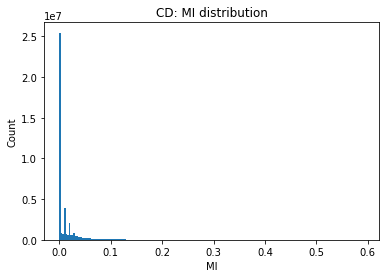


UC distribution (n=49493084 sampled values)
min, median, 75%, 90%, 95%, 99%, 99.5%,  99.9%, max:
[0.0, 8.881784197001252e-16, 0.0303030303030311, 0.05997228172115614, 0.08688500279937167, 0.16220793925052734, 0.1983781204175938, 0.2807587872729885, 0.7148763575761885]


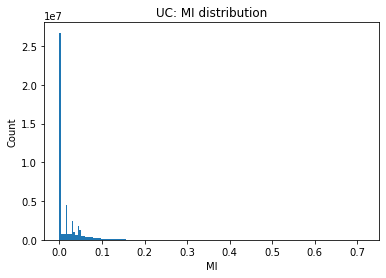


nonIBD distribution (n=49926561 sampled values)
min, median, 75%, 90%, 95%, 99%, 99.5%,  99.9%, max:
[0.0, 0.0, 0.0317460317460318, 0.0658730158730163, 0.0976336833756121, 0.1832436424044123, 0.2213227926430071, 0.3077568887940414, 0.737264432825026]


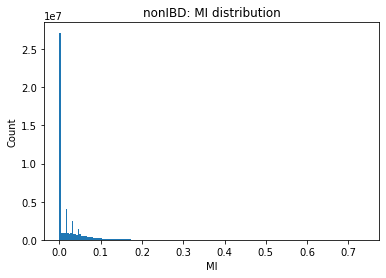

In [5]:


def plot_mi_distribution(df, name, bins=200, sample_size=2_000_000, seed=0):
    A = df.values.astype(float).ravel()  # volver lista la tabla 
    A = A[np.isfinite(A)]                # remove NaN/inf if any


    # Print key quantiles (helps pick thresholds later)
    qs = np.quantile(A, [0.0, 0.5, 0.75, 0.9, 0.95, 0.99, 0.995, 0.999, 1.0])
    print(f"\n{name} distribution (n={A.size} sampled values)")
    print("min, median, 75%, 90%, 95%, 99%, 99.5%,  99.9%, max:")
    print([float(x) for x in qs])

    # Histogram
    plt.figure()
    plt.hist(A, bins=bins)
    plt.title(f"{name}: MI distribution")
    plt.xlabel("MI")
    plt.ylabel("Count")
    plt.show()

  

plot_mi_distribution(df_cd, "CD")
plot_mi_distribution(df_uc, "UC")
plot_mi_distribution(df_nibd, "nonIBD")


In [7]:
#filtrar edges 

def edges_at_percentile(df, name, q=0.9995):
    A = df.values.astype(float)
    thr = float(np.quantile(A, q))

    # Filter positions where MI >= threshold
    rows, cols = np.where(A >= thr)

    edges = pd.DataFrame({
        "micro": df.index[rows],
        "tx": df.columns[cols],
        "weight": A[rows, cols]
    })

    edges = edges.sort_values("weight", ascending=False).reset_index(drop=True)

    print(f"{name} | q={q} | threshold={thr:.6f} | edges={len(edges)}")
    return thr, edges

thr_cd, edges_cd = edges_at_percentile(df_cd, "CD", q=0.9995)
thr_uc, edges_uc = edges_at_percentile(df_uc, "UC", q=0.9995)
thr_nibd, edges_nibd = edges_at_percentile(df_nibd, "nonIBD", q=0.9995)

# Optional: save for later steps
edges_cd.to_csv("breadbox_edges_CD_q9995with0.csv", index=False)
edges_uc.to_csv("breadbox_edges_UC_q9995with0.csv", index=False)
edges_nibd.to_csv("breadbox_edges_nonIBD_q9995with0.csv", index=False)

CD | q=0.9995 | threshold=0.275264 | edges=21068
UC | q=0.9995 | threshold=0.315248 | edges=24747
nonIBD | q=0.9995 | threshold=0.344967 | edges=24964


In [8]:
edges_cd.head()

,micro,tx,weight
0,micro__Bacteria; __Bacteroidetes; __Bacteroidi...,tx__CTCFL,0.592364
1,micro__Bacteria; __Bacteroidetes; __Bacteroidi...,tx__CTCFL,0.561366
2,micro__Bacteria; __Bacteroidetes; __Bacteroidi...,tx__CTCFL,0.561355
3,micro__Bacteria; __Firmicutes; __Clostridia; _...,tx__PSG9,0.548272
4,micro__Bacteria; __Bacteroidetes; __Bacteroidi...,tx__CTCFL,0.546600


In [10]:
edges_cd.shape

(21068, 3)

In [13]:
# Filtrar matriz y volverla binaria


def binarize_full_matrix(df, name, q=0.9995):
    A = df.values.astype(float)
    thr = float(np.quantile(A, q))

    bin_A = (A >= thr).astype(int)
    bin_df = pd.DataFrame(bin_A, index=df.index, columns=df.columns)

    n_edges = int(bin_A.sum())
    print(f"{name} | q={q} | threshold={thr:.6f} | binary_edges={n_edges} | shape={bin_df.shape}")

    return thr, bin_df


thr_cd, bin_df_cd = binarize_full_matrix(df_cd, "CD", q=0.9995)
thr_uc, bin_df_uc = binarize_full_matrix(df_uc, "UC", q=0.9995)
thr_nibd, bin_df_nibd = binarize_full_matrix(df_nibd, "nonIBD", q=0.9995)





print("CD:    edges =", int(bin_df_cd.to_numpy().sum()), "shape =", bin_df_cd.shape)
print("UC:    edges =", int(bin_df_uc.to_numpy().sum()), "shape =", bin_df_uc.shape)
print("nonIBD: edges =", int(bin_df_nibd.to_numpy().sum()), "shape =", bin_df_nibd.shape)

# opcional
bin_df_cd.to_csv("MI_lasbuenas/bin_MI_CD9mar.csv")
bin_df_uc.to_csv("MI_lasbuenas/bin_MI_UC9mar.csv")
bin_df_nibd.to_csv("MI_lasbuenas/bin_MI_nonIBD9mar.csv")

#output: csv con matriz del mismo tamaño pero 1 y 0 (binaria)
# fil_cd, _nonibd fil_uc y fil 

CD | q=0.9995 | threshold=0.275264 | binary_edges=21068 | shape=(2429, 17345)
UC | q=0.9995 | threshold=0.315248 | binary_edges=24747 | shape=(2876, 17209)
nonIBD | q=0.9995 | threshold=0.344967 | binary_edges=24964 | shape=(2911, 17151)
CD:    edges = 21068 shape = (2429, 17345)
UC:    edges = 24747 shape = (2876, 17209)
nonIBD: edges = 24964 shape = (2911, 17151)


In [14]:
def build_bipartite_full(bin_df, name):
    B = nx.Graph()

    micros = list(bin_df.index)
    txs = list(bin_df.columns)

    # Add all nodes first
    B.add_nodes_from(micros, bipartite=0, node_type="micro")
    B.add_nodes_from(txs, bipartite=1, node_type="tx")

    # Add only edges where binary matrix == 1
    A = bin_df.values
    rows, cols = np.where(A == 1)

    for r, c in zip(rows, cols):
        B.add_edge(bin_df.index[r], bin_df.columns[c], weight=1)

    n_micro = len(micros)
    n_tx = len(txs)
    n_edges = B.number_of_edges()
    n_isolates = len(list(nx.isolates(B)))

    print(f"{name} | micro={n_micro} | tx={n_tx} | total_nodes={B.number_of_nodes()} | edges={n_edges} | isolates={n_isolates}")

    return B


B_cd_full = build_bipartite_full(bin_df_cd, "CD")
B_uc_full = build_bipartite_full(bin_df_uc, "UC")
B_nibd_full = build_bipartite_full(bin_df_nibd, "nonIBD")


CD | micro=2429 | tx=17345 | total_nodes=19774 | edges=21068 | isolates=14226
UC | micro=2876 | tx=17209 | total_nodes=20085 | edges=24747 | isolates=13863
nonIBD | micro=2911 | tx=17151 | total_nodes=20062 | edges=24964 | isolates=14118


In [15]:
def edge_list_from_binary(bin_df, name):
    A = bin_df.values
    rows, cols = np.where(A == 1)

    edges = pd.DataFrame({
        "micro": bin_df.index[rows],
        "tx": bin_df.columns[cols],
        "weight": A[rows, cols]
    })

    edges = edges.sort_values(["micro", "tx"]).reset_index(drop=True)
    print(f"{name} | exported binary edge list with {len(edges)} edges")

    return edges


edges_cd_full = edge_list_from_binary(bin_df_cd, "CD")
edges_uc_full = edge_list_from_binary(bin_df_uc, "UC")
edges_nibd_full = edge_list_from_binary(bin_df_nibd, "nonIBD")


CD | exported binary edge list with 21068 edges
UC | exported binary edge list with 24747 edges
nonIBD | exported binary edge list with 24964 edges


In [16]:
def node_table_from_graph(B, name):
    rows = []

    for node, attrs in B.nodes(data=True):
        rows.append({
            "node": node,
            "node_type": attrs.get("node_type"),
            "bipartite": attrs.get("bipartite"),
            "degree": B.degree(node),
            "is_isolate": int(B.degree(node) == 0)
        })

    df_nodes = pd.DataFrame(rows).sort_values(
        by=["node_type", "degree", "node"],
        ascending=[True, False, True]
    ).reset_index(drop=True)

    print(f"{name} | node table shape = {df_nodes.shape}")
    return df_nodes


nodes_cd_full = node_table_from_graph(B_cd_full, "CD")
nodes_uc_full = node_table_from_graph(B_uc_full, "UC")
nodes_nibd_full = node_table_from_graph(B_nibd_full, "nonIBD")



CD | node table shape = (19774, 5)
UC | node table shape = (20085, 5)
nonIBD | node table shape = (20062, 5)


In [17]:
thresholds_full_rebuild = pd.DataFrame({
    "network": ["CD", "UC", "nonIBD"],
    "q": [0.9995, 0.9995, 0.9995],
    "threshold": [thr_cd, thr_uc, thr_nibd]
})
thresholds_full_rebuild.to_csv("breadbox_thresholds_full_rebuild_q9995_KEEPALLNODES.csv", index=False)

# Binary matrices
bin_df_cd.to_csv("breadbox_binary_matrix_CD_q9995_KEEPALLNODES.csv")
bin_df_uc.to_csv("breadbox_binary_matrix_UC_q9995_KEEPALLNODES.csv")
bin_df_nibd.to_csv("breadbox_binary_matrix_nonIBD_q9995_KEEPALLNODES.csv")

# Edge lists
edges_cd_full.to_csv("breadbox_edges_CD_q9995_KEEPALLNODES_FULL.csv", index=False)
edges_uc_full.to_csv("breadbox_edges_UC_q9995_KEEPALLNODES_FULL.csv", index=False)
edges_nibd_full.to_csv("breadbox_edges_nonIBD_q9995_KEEPALLNODES_FULL.csv", index=False)

# Node tables
nodes_cd_full.to_csv("breadbox_nodes_CD_q9995_KEEPALLNODES_FULL.csv", index=False)
nodes_uc_full.to_csv("breadbox_nodes_UC_q9995_KEEPALLNODES_FULL.csv", index=False)
nodes_nibd_full.to_csv("breadbox_nodes_nonIBD_q9995_KEEPALLNODES_FULL.csv", index=False)

# GraphML
nx.write_graphml(B_cd_full, "breadbox_bipartite_CD_q9995_KEEPALLNODES_FULL.graphml")
nx.write_graphml(B_uc_full, "breadbox_bipartite_UC_q9995_KEEPALLNODES_FULL.graphml")
nx.write_graphml(B_nibd_full, "breadbox_bipartite_nonIBD_q9995_KEEPALLNODES_FULL.graphml")



In [18]:
def graph_summary(B, name):
    n_nodes = B.number_of_nodes()
    n_edges = B.number_of_edges()
    n_isolates = len(list(nx.isolates(B)))

    micro_nodes = [n for n, d in B.nodes(data=True) if d.get("node_type") == "micro"]
    tx_nodes = [n for n, d in B.nodes(data=True) if d.get("node_type") == "tx"]

    print(f"\n{name}")
    print(f"  total_nodes: {n_nodes}")
    print(f"  micro_nodes: {len(micro_nodes)}")
    print(f"  tx_nodes: {len(tx_nodes)}")
    print(f"  edges: {n_edges}")
    print(f"  isolates: {n_isolates}")


graph_summary(B_cd_full, "CD")
graph_summary(B_uc_full, "UC")
graph_summary(B_nibd_full, "nonIBD")


CD
  total_nodes: 19774
  micro_nodes: 2429
  tx_nodes: 17345
  edges: 21068
  isolates: 14226

UC
  total_nodes: 20085
  micro_nodes: 2876
  tx_nodes: 17209
  edges: 24747
  isolates: 13863

nonIBD
  total_nodes: 20062
  micro_nodes: 2911
  tx_nodes: 17151
  edges: 24964
  isolates: 14118


In [19]:
# comprobar que sea bipartita (los nodos micro vayan solo a tx y viceversa)

for name, B in [("CD", B_cd_full), ("UC", B_uc_full), ("nonIBD", B_nibd_full)]:
    is_bip = bipartite.is_bipartite(B)
    print(f"{name} | Is bipartite? {is_bip} | nodes={B.number_of_nodes()} | edges={B.number_of_edges()} | isolates={len(list(nx.isolates(B)))}")

CD | Is bipartite? True | nodes=19774 | edges=21068 | isolates=14226
UC | Is bipartite? True | nodes=20085 | edges=24747 | isolates=13863
nonIBD | Is bipartite? True | nodes=20062 | edges=24964 | isolates=14118


In [20]:
#cuantos componentes tiene c/u 

for name, B in [("CD", B_cd_full), ("UC", B_uc_full), ("nonIBD", B_nibd_full)]:
    components2 = list(nx.connected_components(B))
    sizes = sorted([len(c) for c in components2], reverse=True)

    print(f"\n{name}")
    print("  #components:", len(components2))
    print("  largest component size:", sizes[0] if sizes else 0)
    print("  top 5 component sizes:", sizes[:5])
    print("  isolates:", len(list(nx.isolates(B))))





CD
  #components: 14277
  largest component size: 5438
  top 5 component sizes: [5438, 4, 3, 3, 3]
  isolates: 14226

UC
  #components: 13880
  largest component size: 6189
  top 5 component sizes: [6189, 3, 2, 2, 2]
  isolates: 13863

nonIBD
  #components: 14165
  largest component size: 5841
  top 5 component sizes: [5841, 4, 4, 3, 3]
  isolates: 14118


In [21]:
# componente más grande

for name, B in [("CD", B_cd_full), ("UC", B_uc_full), ("nonIBD", B_nibd_full)]:
    components2 = list(nx.connected_components(B))
    largest_size = max((len(c) for c in components2), default=0)
    print(f"{name} | largest component size: {largest_size} | total_nodes: {B.number_of_nodes()} | isolates: {len(list(nx.isolates(B)))}")

CD | largest component size: 5438 | total_nodes: 19774 | isolates: 14226
UC | largest component size: 6189 | total_nodes: 20085 | isolates: 13863
nonIBD | largest component size: 5841 | total_nodes: 20062 | isolates: 14118


In [22]:
# hay componente gigante? 
for name, B in [("CD", B_cd_full), ("UC", B_uc_full), ("nonIBD", B_nibd_full)]:
    components2 = list(nx.connected_components(B))
    largest_size = max((len(c) for c in components2), default=0)

    threshold_nodes = math.floor(B.number_of_nodes() / 2) + 1

    print(f"\n{name}")
    print("Largest component size:", largest_size)
    print("Threshold (50% + 1):", threshold_nodes)
    print("Total nodes:", B.number_of_nodes())
    print("Isolates:", len(list(nx.isolates(B))))

    if largest_size >= threshold_nodes:
        print("Hay componente gigante :)")
    else:
        print("No hay componente gigante")


CD
Largest component size: 5438
Threshold (50% + 1): 9888
Total nodes: 19774
Isolates: 14226
No hay componente gigante

UC
Largest component size: 6189
Threshold (50% + 1): 10043
Total nodes: 20085
Isolates: 13863
No hay componente gigante

nonIBD
Largest component size: 5841
Threshold (50% + 1): 10032
Total nodes: 20062
Isolates: 14118
No hay componente gigante


In [23]:

def top_degree_centrality(B: nx.Graph, top_k: int = 10):
    degree_centrality2 = nx.degree_centrality(B)

    # sort from highest to lowest
    top = sorted(degree_centrality2.items(), key=lambda x: x[1], reverse=True)[:top_k]

    print(f"Top {top_k} nodes by degree centrality:")
    for node, score in top:
        node_type = B.nodes[node].get("node_type")
        print(f"  {node_type:>5} | {node} | {score:.4f}")

# for the 3 full graphs
for name, B in [("CD", B_cd_full), ("UC", B_uc_full), ("nonIBD", B_nibd_full)]:
    print(f"\n=== {name} ===")
    top_degree_centrality(B, top_k=10)
    
# obtener la tabla en CSV para cada una para genes y para bichos 


=== CD ===
Top 10 nodes by degree centrality:
  micro | micro__Bacteria; __Bacteroidetes; __Bacteroidia; __Bacteroidales; __Porphyromonadaceae; __Odoribacter.2 | 0.0484
  micro | micro__Bacteria; __Bacteroidetes; __Bacteroidia; __Bacteroidales; __Prevotellaceae; __Prevotella_6.10 | 0.0483
  micro | micro__Bacteria; __Firmicutes; __Clostridia; __Clostridiales; __Ruminococcaceae; __Ruminococcaceae_UCG_014.9 | 0.0329
  micro | micro__Bacteria; __Firmicutes; __Clostridia; __Clostridiales; __Christensenellaceae; __Christensenellaceae_R_7_group.72 | 0.0296
  micro | micro__Bacteria; __Firmicutes; __Erysipelotrichia; __Erysipelotrichales; __Erysipelotrichaceae; __uncultured | 0.0260
  micro | micro__Bacteria; __Firmicutes; __Clostridia; __Clostridiales; __Ruminococcaceae; __uncultured.678 | 0.0233
  micro | micro__Bacteria; __Firmicutes; __Clostridia; __Clostridiales; __Ruminococcaceae; __uncultured.149 | 0.0228
  micro | micro__Bacteria; __Firmicutes; __Bacilli; __Lactobacillales; __Lactoba

In [24]:
#guardar y exportar cosas 

# exportar a graphml 
nx.write_graphml(B_cd_full,   "MI_lasbuenas/B_cd_full_KEEPALLNODES_q9995.graphml")
nx.write_graphml(B_uc_full,   "MI_lasbuenas/B_uc_full_KEEPALLNODES_q9995.graphml")
nx.write_graphml(B_nibd_full, "MI_lasbuenas/B_nibd_full_KEEPALLNODES_q9995.graphml")


#  export edge lists + node lists 
def export_lists(B: nx.Graph, prefix: str):
    edges = nx.to_pandas_edgelist(B)
    edges.to_csv(f"MI_lasbuenas/{prefix}_edges_KEEPALLNODES_q9995.csv", index=False)

    nodes = pd.DataFrame(
        [{"node": n, **d} for n, d in B.nodes(data=True)]
    )
    nodes.to_csv(f"MI_lasbuenas/{prefix}_nodes_KEEPALLNODES_q9995.csv", index=False)

export_lists(B_cd_full, "B_cd_full")
export_lists(B_uc_full, "B_uc_full")
export_lists(B_nibd_full, "B_nibd_full")

print("Saved: GraphML + edges.csv + nodes.csv for CD/UC/nonIBD (KEEPALLNODES_q9995)")

Saved: GraphML + edges.csv + nodes.csv for CD/UC/nonIBD (KEEPALLNODES_q9995)


In [25]:
! pip install igraph


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [26]:
#hacer la prueba en igraph 
import igraph as ig

In [27]:
def nx_to_igraph(B_nx):
    nodes = list(B_nx.nodes())
    idx = {n: i for i, n in enumerate(nodes)}
    edges = [(idx[u], idx[v]) for u, v in B_nx.edges()]

    g = ig.Graph(n=len(nodes), edges=edges, directed=False)
    g.vs["name"] = nodes

    # keep node attributes when possible
    g.vs["node_type"] = [B_nx.nodes[n].get("node_type") for n in nodes]
    g.vs["bipartite"] = [B_nx.nodes[n].get("bipartite") for n in nodes]

    return g

In [28]:
b_cd_full = nx_to_igraph(B_cd_full)
components = b_cd_full.connected_components()
num_components = len(components)
print(num_components)

14277


In [29]:
def bipartite_node_sets(B: nx.Graph):
    micros = [n for n, d in B.nodes(data=True) if d.get("node_type") == "micro"]
    txs = [n for n, d in B.nodes(data=True) if d.get("node_type") == "tx"]
    return micros, txs

def summarize_bipartite_clustering(B: nx.Graph, name: str):
    micros, txs = bipartite_node_sets(B)

    # bipartite clustering for each side
    cl_micro = bipartite.clustering(B, nodes=micros)
    cl_tx = bipartite.clustering(B, nodes=txs)

    v_micro = np.array(list(cl_micro.values()), dtype=float)
    v_tx = np.array(list(cl_tx.values()), dtype=float)

    print(f"\n{name}")
    print("  micro | n =", len(micros),
          "| avg =", float(v_micro.mean()) if v_micro.size else 0.0,
          "| median =", float(np.median(v_micro)) if v_micro.size else 0.0,
          "| max =", float(v_micro.max()) if v_micro.size else 0.0)

    print("    tx  | n =", len(txs),
          "| avg =", float(v_tx.mean()) if v_tx.size else 0.0,
          "| median =", float(np.median(v_tx)) if v_tx.size else 0.0,
          "| max =", float(v_tx.max()) if v_tx.size else 0.0)

# run for the 3 full networks
summarize_bipartite_clustering(B_cd_full, "CD")
summarize_bipartite_clustering(B_uc_full, "UC")
summarize_bipartite_clustering(B_nibd_full, "nonIBD")

#clustering dot de latapy





CD
  micro | n = 2429 | avg = 0.08977798323052162 | median = 0.03649467100097242 | max = 1.0
    tx  | n = 17345 | avg = 0.07582530067308384 | median = 0.0 | max = 1.0

UC
  micro | n = 2876 | avg = 0.1018608356869212 | median = 0.08446374977554622 | max = 1.0
    tx  | n = 17209 | avg = 0.06319479625367584 | median = 0.0 | max = 0.9247311827956989

nonIBD
  micro | n = 2911 | avg = 0.08808374045011103 | median = 0.0 | max = 1.0
    tx  | n = 17151 | avg = 0.1135752089982304 | median = 0.0 | max = 1.0


In [30]:

from collections import Counter

def degree_freq_by_type(B):
    # split nodes by node_type ("micro" / "tx")
    micros = [n for n, d in B.nodes(data=True) if d.get("node_type") == "micro"]
    txs    = [n for n, d in B.nodes(data=True) if d.get("node_type") == "tx"]

    micro_deg = [B.degree(n) for n in micros]
    tx_deg    = [B.degree(n) for n in txs]

    micro_counts = Counter(micro_deg)
    tx_counts    = Counter(tx_deg)

    # sort by degree for plotting
    micro_xy = sorted(micro_counts.items())  # (degree, freq)
    tx_xy    = sorted(tx_counts.items())

    micro_x = np.array([k for k, v in micro_xy], dtype=float)
    micro_y = np.array([v for k, v in micro_xy], dtype=float)

    tx_x = np.array([k for k, v in tx_xy], dtype=float)
    tx_y = np.array([v for k, v in tx_xy], dtype=float)

    return (micro_x, micro_y), (tx_x, tx_y)

def plot_degree_distribution(ax, B, title):
    (mx, my), (tx, ty) = degree_freq_by_type(B)

    ax.scatter(tx, ty, s=12, label="tx")
    ax.scatter(mx, my, s=12, label="micro")

    # keep only y in log scale so degree 0 can still appear on x
    ax.set_yscale("log")
    ax.set_xlabel("degree")
    ax.set_ylabel("frequency")
    ax.set_title(title)
    ax.legend()

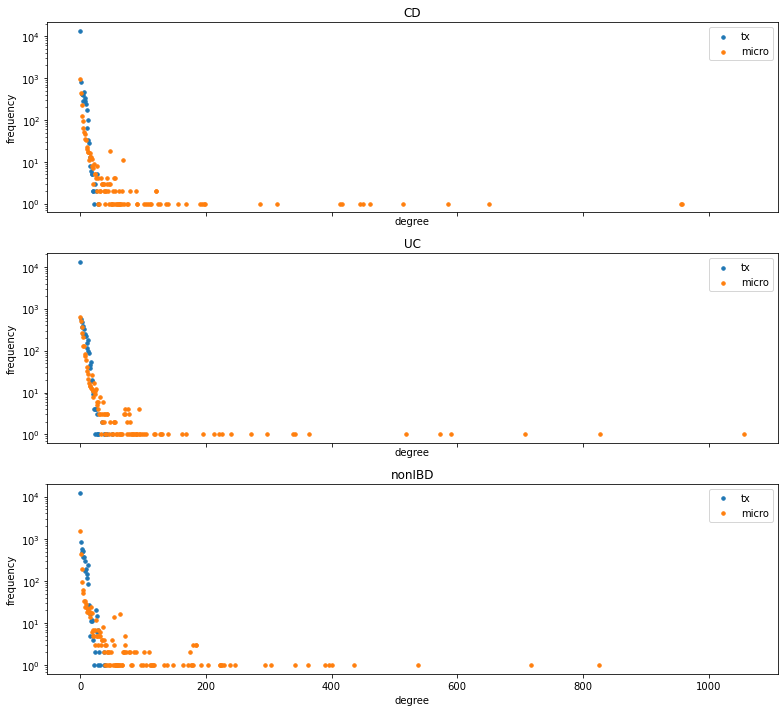

In [31]:

fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True)

plot_degree_distribution(axes[0], B_cd_full, "CD")
plot_degree_distribution(axes[1], B_uc_full, "UC")
plot_degree_distribution(axes[2], B_nibd_full, "nonIBD")

plt.tight_layout()
plt.show()

In [32]:
def bipartite_node_sets(B):
    micros = [n for n, d in B.nodes(data=True) if d.get("node_type") == "micro"]
    txs = [n for n, d in B.nodes(data=True) if d.get("node_type") == "tx"]
    return micros, txs

def safe_node_redundancy(B: nx.Graph) -> dict:
    """
    Compute bipartite.node_redundancy only for nodes with degree >= 2.
    For nodes with degree < 2, set redundancy = 0.0.
    """
    rc = {n: 0.0 for n in B.nodes()}

    eligible = [n for n in B.nodes() if B.degree(n) >= 2]
    if eligible:
        rc_elig = bipartite.node_redundancy(B, nodes=eligible)
        rc.update(rc_elig)

    return rc

def summarize_redundancy(B, name):
    rc_all = safe_node_redundancy(B)

    micros, txs = bipartite_node_sets(B)
    rc_micro = np.array([rc_all[n] for n in micros], dtype=float)
    rc_tx = np.array([rc_all[n] for n in txs], dtype=float)

    print(f"\n{name}")
    print("  micro | n =", len(micros),
          "| avg =", float(rc_micro.mean()) if rc_micro.size else 0.0,
          "| median =", float(np.median(rc_micro)) if rc_micro.size else 0.0,
          "| max =", float(rc_micro.max()) if rc_micro.size else 0.0)
    print("    tx  | n =", len(txs),
          "| avg =", float(rc_tx.mean()) if rc_tx.size else 0.0,
          "| median =", float(np.median(rc_tx)) if rc_tx.size else 0.0,
          "| max =", float(rc_tx.max()) if rc_tx.size else 0.0)

    return rc_all

rc_cd_full = summarize_redundancy(B_cd_full, "CD")
rc_uc_full = summarize_redundancy(B_uc_full, "UC")
rc_nibd_full = summarize_redundancy(B_nibd_full, "nonIBD")


# dibujito y tablita de 10 de redundancia !!!!!
# y tablita de 10 de clustering 


CD
  micro | n = 2429 | avg = 0.1598669235796172 | median = 0.0 | max = 1.0
    tx  | n = 17345 | avg = 0.13783469094740902 | median = 0.0 | max = 1.0

UC
  micro | n = 2876 | avg = 0.2159171145646581 | median = 0.0 | max = 1.0
    tx  | n = 17209 | avg = 0.13527654764863775 | median = 0.0 | max = 1.0

nonIBD
  micro | n = 2911 | avg = 0.18692962307414773 | median = 0.0 | max = 1.0
    tx  | n = 17151 | avg = 0.18100855989877324 | median = 0.0 | max = 1.0


Hairball - CD | nodes=5438 edges=21008


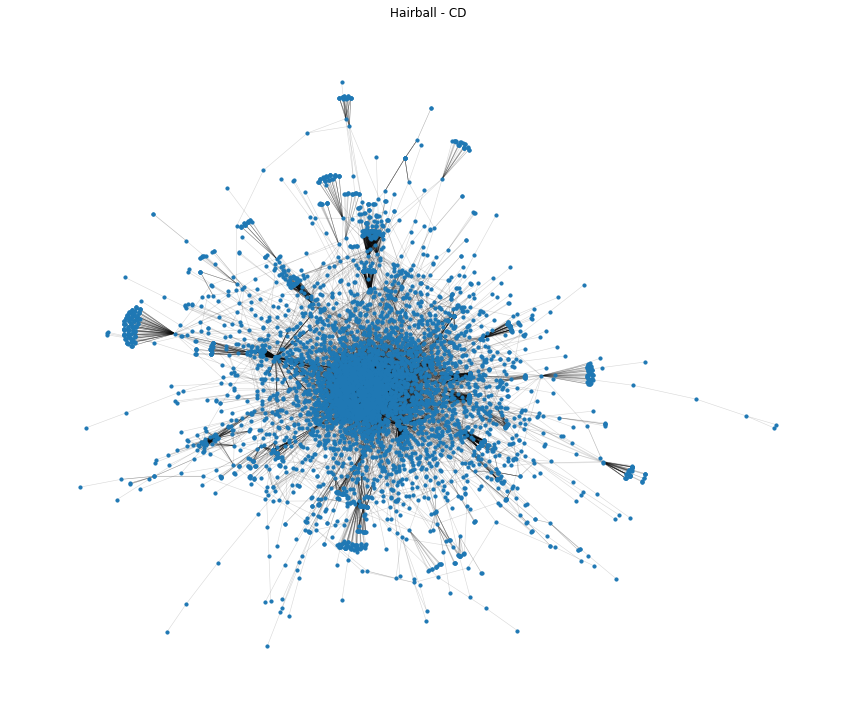

Hairball - UC | nodes=6189 edges=24730


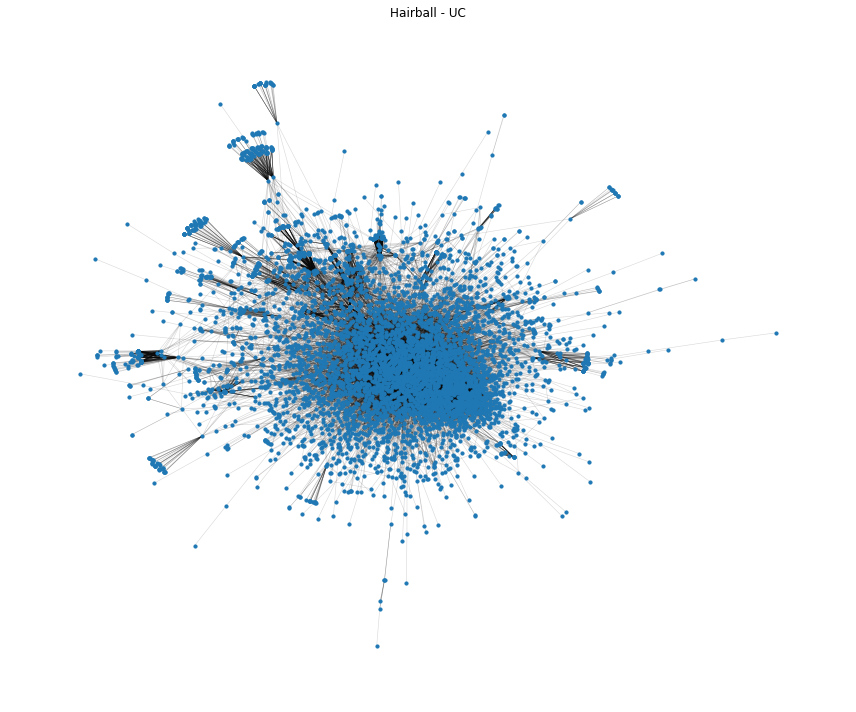

Hairball - nonIBD | nodes=5841 edges=24907


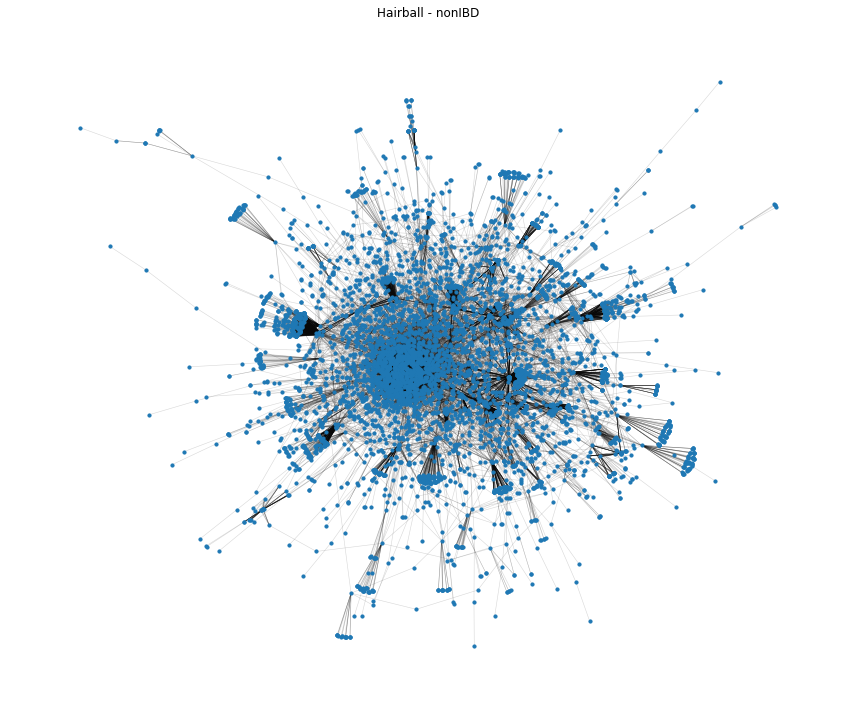

In [33]:
def hairball(B, title, use_largest_cc=True, remove_isolates=True, seed=7):
    G = B.copy()

    if remove_isolates:
        G.remove_nodes_from(list(nx.isolates(G)))

    if use_largest_cc and G.number_of_nodes() > 0:
        largest_cc = max(nx.connected_components(G), key=len)
        G = G.subgraph(largest_cc).copy()

    print(f"{title} | nodes={G.number_of_nodes()} edges={G.number_of_edges()}")

    # layout
    pos = nx.spring_layout(G, seed=seed, k=None)

    plt.figure(figsize=(12, 10))
    nx.draw_networkx_edges(G, pos, alpha=0.15, width=0.6)
    nx.draw_networkx_nodes(G, pos, node_size=10)
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

# hairballs
hairball(B_cd_full, "Hairball - CD", use_largest_cc=True, remove_isolates=True)
hairball(B_uc_full, "Hairball - UC", use_largest_cc=True, remove_isolates=True)
hairball(B_nibd_full, "Hairball - nonIBD", use_largest_cc=True, remove_isolates=True)



#output 
#grafo completo graphml con todas las propiedades de los nodos
#output: tablitas 

In [34]:

def node_table(B: nx.Graph) -> pd.DataFrame:
    rows = []
    deg = dict(B.degree())
    dc = nx.degree_centrality(B)

    for n, d in B.nodes(data=True):
        node_type = d.get("node_type")  # "micro" or "tx"
        rows.append({
            "node": n,
            "type": node_type,
            "degree": int(deg.get(n, 0)),
            "centrality": float(dc.get(n, 0.0))
        })

    out = pd.DataFrame(rows)

    out["node_tx"] = out.apply(lambda r: r["node"] if r["type"] == "tx" else pd.NA, axis=1)
    out["node_micro"] = out.apply(lambda r: r["node"] if r["type"] == "micro" else pd.NA, axis=1)

    out = out[["node_tx", "node_micro", "centrality", "degree", "type", "node"]]
    out = out.sort_values(["degree", "centrality"], ascending=False).reset_index(drop=True)
    return out

table_cd_full = node_table(B_cd_full)
table_uc_full = node_table(B_uc_full)
table_nibd_full = node_table(B_nibd_full)

# save with new names to avoid overwriting
table_cd_full.to_csv("MI_lasbuenas/nodes_CD_centrality_degree_KEEPALLNODES_q9995_full.csv", index=False)
table_uc_full.to_csv("MI_lasbuenas/nodes_UC_centrality_degree_KEEPALLNODES_q9995_full.csv", index=False)
table_nibd_full.to_csv("MI_lasbuenas/nodes_nonIBD_centrality_degree_KEEPALLNODES_q9995_full.csv", index=False)

print(table_cd_full.head(10))




  node_tx                                         node_micro  centrality  \
0    <NA>  micro__Bacteria; __Bacteroidetes; __Bacteroidi...    0.048450   
1    <NA>  micro__Bacteria; __Bacteroidetes; __Bacteroidi...    0.048349   
2    <NA>  micro__Bacteria; __Firmicutes; __Clostridia; _...    0.032873   
3    <NA>  micro__Bacteria; __Firmicutes; __Clostridia; _...    0.029586   
4    <NA>  micro__Bacteria; __Firmicutes; __Erysipelotric...    0.025995   
5    <NA>  micro__Bacteria; __Firmicutes; __Clostridia; _...    0.023315   
6    <NA>  micro__Bacteria; __Firmicutes; __Clostridia; _...    0.022758   
7    <NA>  micro__Bacteria; __Firmicutes; __Bacilli; __La...    0.022505   
8    <NA>  micro__Bacteria; __Firmicutes; __Clostridia; _...    0.021089   
9    <NA>  micro__Bacteria; __Firmicutes; __Clostridia; _...    0.020887   

   degree   type                                               node  
0     958  micro  micro__Bacteria; __Bacteroidetes; __Bacteroidi...  
1     956  micro  micro

In [35]:
def safe_node_redundancy(B: nx.Graph) -> dict:
    rc = {n: 0.0 for n in B.nodes()}
    eligible = [n for n in B.nodes() if B.degree(n) >= 2]
    if eligible:
        rc.update(bipartite.node_redundancy(B, nodes=eligible))
    return rc

def node_table_full(B: nx.Graph) -> pd.DataFrame:
    deg = dict(B.degree())
    deg_cent = nx.degree_centrality(B)
    btw = nx.betweenness_centrality(B)

    # bipartite clustering by side
    micros = [n for n, d in B.nodes(data=True) if d.get("node_type") == "micro"]
    txs = [n for n, d in B.nodes(data=True) if d.get("node_type") == "tx"]
    cl_micro = bipartite.clustering(B, nodes=micros)
    cl_tx = bipartite.clustering(B, nodes=txs)
    bip_clust = {**cl_micro, **cl_tx}

    # Latapy redundancy
    red = safe_node_redundancy(B)

    # components + GCC flag
    comps = list(nx.connected_components(B))
    comp_id = {}
    for i, comp in enumerate(comps):
        for n in comp:
            comp_id[n] = i
    gcc_nodes = set(max(comps, key=len)) if comps else set()

    rows = []
    for n, d in B.nodes(data=True):
        t = d.get("node_type")
        rows.append({
            "node": n,
            "type": t,
            "degree": int(deg.get(n, 0)),
            "degree_centrality": float(deg_cent.get(n, 0.0)),
            "betweenness": float(btw.get(n, 0.0)),
            "bipartite_clustering": float(bip_clust.get(n, 0.0)),
            "redundancy_latapy": float(red.get(n, 0.0)),
            "component_id": int(comp_id.get(n, -1)),
            "in_gcc": int(n in gcc_nodes),
        })

    out = pd.DataFrame(rows)

    out["node_tx"] = np.where(out["type"] == "tx", out["node"], pd.NA)
    out["node_micro"] = np.where(out["type"] == "micro", out["node"], pd.NA)

    out = out[[
        "node_tx", "node_micro",
        "type", "degree", "degree_centrality",
        "betweenness", "bipartite_clustering", "redundancy_latapy",
        "component_id", "in_gcc", "node"
    ]].sort_values(
        ["in_gcc", "degree", "betweenness"],
        ascending=[False, False, False]
    ).reset_index(drop=True)

    return out

table_cd_full_metrics = node_table_full(B_cd_full)
table_uc_full_metrics = node_table_full(B_uc_full)
table_nibd_full_metrics = node_table_full(B_nibd_full)

table_cd_full_metrics.to_csv("MI_lasbuenas/nodes_CD_metrics_KEEPALLNODES_q9995_full.csv", index=False)
table_uc_full_metrics.to_csv("MI_lasbuenas/nodes_UC_metrics_KEEPALLNODES_q9995_full.csv", index=False)
table_nibd_full_metrics.to_csv("MI_lasbuenas/nodes_nonIBD_metrics_KEEPALLNODES_q9995_full.csv", index=False)

In [36]:
#correr
def export_graph_as_pandas_and_numpy(B, name, out_dir="MI_lasbuenas", weight=None):
    # 1) make sure the graph already has node metrics attached
    attach_node_metrics(B)

    # 2) fix node order so adjacency matrix and node table match
    nodelist = list(B.nodes())

    # 3) adjacency matrix
    A = nx.to_numpy_array(B, nodelist=nodelist, dtype=float, weight=weight, nonedge=0.0)

    # 4) node table with all attributes
    nodes_df = pd.DataFrame([{"node": n, **attrs} for n, attrs in B.nodes(data=True)])
    nodes_df = nodes_df.set_index("node").loc[nodelist].reset_index()

    # 5) save with new names to avoid overwriting
    np.save(f"{out_dir}/{name}_adjacency_KEEPALLNODES_q9995_full.npy", A)
    nodes_df.to_csv(f"{out_dir}/{name}_nodes_with_metrics_KEEPALLNODES_q9995_full.csv", index=False)

    # optional: edge list with attributes
    edges_df = nx.to_pandas_edgelist(B)
    edges_df.to_csv(f"{out_dir}/{name}_edges_KEEPALLNODES_q9995_full.csv", index=False)

    return nodes_df, A

nodes_cd_full_export, A_cd_full = export_graph_as_pandas_and_numpy(B_cd_full, "CD_full", weight=None)
nodes_uc_full_export, A_uc_full = export_graph_as_pandas_and_numpy(B_uc_full, "UC_full", weight=None)
nodes_nibd_full_export, A_nibd_full = export_graph_as_pandas_and_numpy(B_nibd_full, "nonIBD_full", weight=None)

NameError: name 'attach_node_metrics' is not defined

In [37]:
def export_graph_as_pandas_and_numpy(G: nx.Graph, graph_label: str, weight=None, sort_nodes=True):
    """
    Returns:
      nodes_df: one row per node with its attributes
      A: numpy adjacency matrix (n x n) using the same node order as nodes_df['node']
      edges_df: edge list as a DataFrame (with edge attributes)
    """
    nodelist = list(G.nodes())
    if sort_nodes:
        nodelist = sorted(nodelist, key=lambda x: str(x))

    nodes_df = pd.DataFrame([{"node": n, **G.nodes[n]} for n in nodelist])
    nodes_df.insert(0, "graph", graph_label)

    A = nx.to_numpy_array(G, nodelist=nodelist, weight=weight, dtype=float)

    edges_df = nx.to_pandas_edgelist(G)
    edges_df.insert(0, "graph", graph_label)

    # if weight=None, make the edge weight explicit in the edge table
    if weight is None and "weight" not in edges_df.columns:
        edges_df["weight"] = 1.0

    return nodes_df, A, edges_df


nodes_cd_full_export2, A_cd_full_2, edges_cd_full_export2 = export_graph_as_pandas_and_numpy(
    B_cd_full, "CD_KEEPALLNODES_q9995_full", weight=None, sort_nodes=True
)

nodes_uc_full_export2, A_uc_full_2, edges_uc_full_export2 = export_graph_as_pandas_and_numpy(
    B_uc_full, "UC_KEEPALLNODES_q9995_full", weight=None, sort_nodes=True
)

nodes_nibd_full_export2, A_nibd_full_2, edges_nibd_full_export2 = export_graph_as_pandas_and_numpy(
    B_nibd_full, "nonIBD_KEEPALLNODES_q9995_full", weight=None, sort_nodes=True
)

In [38]:
nodes_cd_full, A_cd_full, edges_cd_full_df = export_graph_as_pandas_and_numpy(
    B_cd_full, "CD_KEEPALLNODES_q9995_full", weight=None
)
nodes_uc_full, A_uc_full, edges_uc_full_df = export_graph_as_pandas_and_numpy(
    B_uc_full, "UC_KEEPALLNODES_q9995_full", weight=None
)
nodes_nibd_full, A_nibd_full, edges_nibd_full_df = export_graph_as_pandas_and_numpy(
    B_nibd_full, "nonIBD_KEEPALLNODES_q9995_full", weight=None
)

nodes_cd_full.head()

,graph,node,bipartite,node_type
0,CD_KEEPALLNODES_q9995_full,micro__Archaea; __Euryarchaeota; __Methanobact...,0,micro
1,CD_KEEPALLNODES_q9995_full,micro__Archaea; __Euryarchaeota; __Methanobact...,0,micro
2,CD_KEEPALLNODES_q9995_full,micro__Archaea; __Euryarchaeota; __Methanobact...,0,micro
3,CD_KEEPALLNODES_q9995_full,micro__Archaea; __WSA2; __WCHA1_57; __o; __f; __g,0,micro
4,CD_KEEPALLNODES_q9995_full,micro__Bacteria; __Actinobacteria; __Actinobac...,0,micro


In [39]:
def top10_by_metric(B, metric, top_k=10, type_attr="node_type"):
    rows = []

    for n, attrs in B.nodes(data=True):
        if metric not in attrs:
            continue

        v = attrs.get(metric)

        # skip missing / NaN
        if v is None:
            continue
        try:
            v = float(v)
        except (TypeError, ValueError):
            continue
        if np.isnan(v):
            continue

        rows.append({
            "node": n,
            "type": attrs.get(type_attr, attrs.get("node_type")),  # fallback
            "value": v
        })

    # if nothing collected, return empty DF with expected columns
    if not rows:
        return pd.DataFrame(columns=["rank", "node", "type", "value"])

    df = pd.DataFrame(rows)

    # extra safety
    if "value" not in df.columns:
        return pd.DataFrame(columns=["rank", "node", "type", "value"])

    df = df.sort_values("value", ascending=False).head(top_k).reset_index(drop=True)
    df.insert(0, "rank", range(1, len(df) + 1))
    return df

In [41]:
def attach_node_metrics(B: nx.Graph):
    deg = dict(B.degree())
    deg_cent = nx.degree_centrality(B)
    btw = nx.betweenness_centrality(B)

    micros = [n for n, d in B.nodes(data=True) if d.get("node_type") == "micro"]
    txs = [n for n, d in B.nodes(data=True) if d.get("node_type") == "tx"]

    cl_micro = bipartite.clustering(B, nodes=micros)
    cl_tx = bipartite.clustering(B, nodes=txs)
    bip_clust = {**cl_micro, **cl_tx}

    red = safe_node_redundancy(B)

    for n in B.nodes():
        B.nodes[n]["degree"] = int(deg.get(n, 0))
        B.nodes[n]["degree_centrality"] = float(deg_cent.get(n, 0.0))
        B.nodes[n]["betweenness"] = float(btw.get(n, 0.0))
        B.nodes[n]["bipartite_clustering"] = float(bip_clust.get(n, 0.0))
        B.nodes[n]["redundancy_latapy"] = float(red.get(n, 0.0))

In [42]:
attach_node_metrics(B_cd_full)
attach_node_metrics(B_uc_full)
attach_node_metrics(B_nibd_full)

In [43]:
METRICS = [
    "degree",
    "degree_centrality",
    "betweenness",
    "bipartite_clustering",
    "redundancy_latapy",
]

GRAPHS = [("CD", B_cd_full), ("UC", B_uc_full), ("nonIBD", B_nibd_full)]

# one csv per metric
for metric in METRICS:
    parts = []
    for gname, B in GRAPHS:
        df_top = top10_by_metric(B, metric, top_k=10)
        if df_top.empty:
            print(f"Skipping {metric} for {gname} (metric not found on nodes)")
            continue
        df_top.insert(0, "graph", gname)
        df_top.insert(1, "metric", metric)
        parts.append(df_top)

    if parts:
        out = pd.concat(parts, ignore_index=True)
        out.to_csv(f"MI_lasbuenas/top10_{metric}_KEEPALLNODES_q9995_full.csv", index=False)
        print(f"Saved MI_lasbuenas/top10_{metric}_KEEPALLNODES_q9995_full.csv")
    else:
        print(f"No output for metric '{metric}' (not present in any graph)")

Saved MI_lasbuenas/top10_degree_KEEPALLNODES_q9995_full.csv
Saved MI_lasbuenas/top10_degree_centrality_KEEPALLNODES_q9995_full.csv
Saved MI_lasbuenas/top10_betweenness_KEEPALLNODES_q9995_full.csv
Saved MI_lasbuenas/top10_bipartite_clustering_KEEPALLNODES_q9995_full.csv
Saved MI_lasbuenas/top10_redundancy_latapy_KEEPALLNODES_q9995_full.csv


In [44]:
nx.write_graphml(B_cd_full, "MI_lasbuenas/B_cd_full_KEEPALLNODES_q9995_WITHMETRICS.graphml")
nx.write_graphml(B_uc_full, "MI_lasbuenas/B_uc_full_KEEPALLNODES_q9995_WITHMETRICS.graphml")
nx.write_graphml(B_nibd_full, "MI_lasbuenas/B_nibd_full_KEEPALLNODES_q9995_WITHMETRICS.graphml")

In [32]:
#input G_x 
# outpput G_x con nodos etiquetados micro o tx propiedad tipo de nodo 
#checar red bipartita y las funciones de ntworkx 


In [33]:
# entran nodos y edges objeto G_x labeled y calcula los componentes conectados 
# output  lista de componentes col con count y participantes
# particiones

# "enriquecimeitno de vecindarios " prueba hipergeometrica prueba exacta de fisher !!!!!!!

In [34]:
# entra objeto G_x labeled y busca si hay un componente gigante 50%+1
# output si/no 